# DINOv3-ViT-S (21M) — Behavior Classification Pipeline

**Goal:** Evaluate Facebook's pre-distilled DINOv3-ViT-S (21M params, dim=384) as a drop-in replacement for DINOv3-ViT-7B (6.7B params, dim=4096) on pig behavior classification.

**Pipeline:**
1. Extract DINOv3-ViT-S embeddings for all cropped frames (CPU-parallel)
2. Save embeddings + create new metadata CSV
3. Train BiLSTM classifier (seq_len=3, stride=1)
4. Comprehensive evaluation: accuracy, F1, confusion matrix, inference speed, top confused pairs

## Cell 1: Install Dependencies

In [0]:
%pip install "numpy<2.0" "transformers>=4.56.0" "torch" "torchvision" "Pillow" "scikit-learn" "seaborn" "matplotlib" --quiet
print("Done — restart kernel if needed")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mosaicml-streaming 0.11.0 requires transformers<5,>=4.21.3, but you have transformers 5.3.0 which is incompatible.
sentence-transformers 3.4.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.3.0 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Done — restart kernel if needed


In [0]:
dbutils.library.restartPython()

## Cell 2: Imports + Configuration

In [0]:
import os, os.path as osp, time, gc, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import multiprocessing as mp

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoImageProcessor, AutoModel
import mlflow
import mlflow.pytorch

# ── Configuration ──────────────────────────────────────────────────────────
# Paths
META_CSV = "/dbfs/mnt/playbehavior/Pig Behavior Edinburgh/Metadata/all_metadata_new.csv"
EMB_OUT_BASE = "/dbfs/mnt/playbehavior/Pig Behavior Edinburgh/All Embeddings_DinoV3_21M"
META_OUT_CSV = "/dbfs/mnt/playbehavior/Pig Behavior Edinburgh/Metadata/metadata_DinoV3.csv"
FIGURE_DIR = "/dbfs/mnt/playbehavior/Pig Behavior Edinburgh/Figures_DinoV3"

os.makedirs(EMB_OUT_BASE, exist_ok=True)
os.makedirs(osp.dirname(META_OUT_CSV), exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Model
MODEL_NAME = "facebook/dinov3-vits16-pretrain-lvd1689m"
EMB_DIM = 384  # ViT-S embedding dimension

# Behaviors
WANTED_BEH = [
    'standing', 'lying', 'eat', 'drink',
    'sitting', 'sleep', 'run', 'playwithtoy', 'nose-to-nose'
]

# LSTM
SEQ_LEN = 3
SEQ_STRIDE = 1
BATCH_SIZE = 128            # A10 24GB has plenty of headroom for LSTM
LR = 1e-3
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 60
PATIENCE = 8

# Parallel extraction — optimised for A10 GPU + 36 cores
# Strategy: 36 threads handle I/O (image load + .pt save),
#           GPU handles batched inference in fp16.
# ViT-S fp16 ≈ 40 MB model + batch of 256 ≈ 1.5 GB → well within 24 GB.
NUM_WORKERS_EXTRACT = min(36, mp.cpu_count())  # Saturate all 36 cores for I/O
EXTRACT_BATCH_SIZE = 256    # Large batches amortise GPU kernel launch overhead
MODEL_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

# Checkpoints
CHECKPOINT_DIR = "/dbfs/mnt/playbehavior/Pig Behavior Edinburgh/Model_Distill/DinoV3_ViTS"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"CPU cores: {mp.cpu_count()}")
print(f"Extraction workers: {NUM_WORKERS_EXTRACT}")
print(f"Extraction batch size: {EXTRACT_BATCH_SIZE}")
print(f"Model dtype: {MODEL_DTYPE}")
print(f"Model: {MODEL_NAME} (dim={EMB_DIM})")

Device: cuda
GPU: NVIDIA A10-24Q
VRAM: 23.7 GB
CPU cores: 36
Extraction workers: 36
Extraction batch size: 256
Model dtype: torch.float16
Model: facebook/dinov3-vits16-pretrain-lvd1689m (dim=384)


## Cell 3: HuggingFace Auth + Load Model

In [0]:
from huggingface_hub import login
login(token="")

print(f"\nLoading {MODEL_NAME} in {MODEL_DTYPE}...")
t0 = time.time()

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
dino_model = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=MODEL_DTYPE)
dino_model.eval()

n_params = sum(p.numel() for p in dino_model.parameters())
bytes_per_param = 2 if MODEL_DTYPE == torch.float16 else 4
size_mb = n_params * bytes_per_param / 1024**2

print(f"Loaded in {time.time()-t0:.1f}s")
print(f"Parameters: {n_params/1e6:.2f}M")
print(f"Size ({MODEL_DTYPE}): {size_mb:.1f} MB")

# Quick test on target device
dino_model = dino_model.to(DEVICE)
dummy = Image.new('RGB', (224, 224))
inputs = processor(images=dummy, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out = dino_model(**inputs)
print(f"Pooled output shape: {out.pooler_output.shape} (dtype={out.pooler_output.dtype})")
print(f"Expected: [1, {EMB_DIM}]")
assert out.pooler_output.shape[-1] == EMB_DIM, f"Dimension mismatch!"
print("OK")

if torch.cuda.is_available():
    vram_used = torch.cuda.memory_allocated() / 1024**2
    print(f"VRAM after model load: {vram_used:.0f} MB")

del dummy, inputs, out


Loading facebook/dinov3-vits16-pretrain-lvd1689m in torch.float16...


preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loaded in 2.0s
Parameters: 21.60M
Size (torch.float16): 41.2 MB
Pooled output shape: torch.Size([1, 384]) (dtype=torch.float16)
Expected: [1, 384]
OK
VRAM after model load: 51 MB


## Cell 4: Load Metadata

In [0]:
df = pd.read_csv(META_CSV)
print(f"Loaded {len(df)} rows from metadata")
print(f"Columns: {list(df.columns)}")
print(f"\nBehavior distribution:")
print(df['behavior'].value_counts().to_string())
print(f"\nSample rows:")
df.head(3)

## Cell 5: Extract DINOv3-ViT-S Embeddings (Parallel I/O + GPU Batched Inference)

**Strategy for A10 GPU + 36 cores:**
- `ThreadPoolExecutor(36)` loads + preprocesses images in parallel (I/O bound)
- Batched inference on GPU in fp16 (batch=256, ~1.5GB VRAM)
- `ThreadPoolExecutor(36)` saves `.pt` files in parallel (I/O bound)

This saturates all 36 cores on I/O while keeping GPU busy on large batches.

In [0]:

# EMBEDDING EXTRACTION — PARALLEL I/O + BATCHED INFERENCE


def build_embedding_path(cropped_frame_path):
    """Convert cropped_frame path → embedding output path.
    
    Input:  .../All Cropped Frames/2019_11_05_000002/pig_3/0000001_pig3.jpg
    Output: .../All Embeddings_DinoV3_21M/2019_11_05_000002/pig_3/0000001_pig3.pt
    """
    # Extract: clip_id/pig_X/filename.jpg
    parts = cropped_frame_path.replace('\\', '/').split('/')
    # Find 'All Cropped Frames' and take everything after it
    try:
        idx = next(i for i, p in enumerate(parts) if 'All Cropped Frames' in p)
        relative = '/'.join(parts[idx+1:])  # clip_id/pig_X/filename.jpg
    except StopIteration:
        # Fallback: use last 3 parts
        relative = '/'.join(parts[-3:])
    
    relative_pt = osp.splitext(relative)[0] + '.pt'
    return osp.join(EMB_OUT_BASE, relative_pt)


def load_and_preprocess(path):
    """Load image from disk and preprocess (runs in thread pool)."""
    try:
        img = Image.open(path).convert('RGB')
        return processor(images=img, return_tensors='pt')
    except Exception as e:
        return None


def save_embedding(args):
    """Save a single embedding to disk (runs in thread pool)."""
    emb_tensor, out_path = args
    os.makedirs(osp.dirname(out_path), exist_ok=True)
    torch.save(emb_tensor, out_path)


# ── Check what's already extracted ─────────────────────────────────────────
all_cropped = df['cropped_frame'].tolist()
all_emb_paths = [build_embedding_path(p) for p in all_cropped]

# Find which embeddings are missing
to_extract = []
for i, (crop_path, emb_path) in enumerate(zip(all_cropped, all_emb_paths)):
    if not osp.exists(emb_path):
        to_extract.append((i, crop_path, emb_path))

print(f"Total frames: {len(all_cropped)}")
print(f"Already extracted: {len(all_cropped) - len(to_extract)}")
print(f"Need to extract: {len(to_extract)}")

if len(to_extract) > 0:
    # Model is already on DEVICE from Cell 3
    infer_device = DEVICE
    
    print(f"\nExtracting {len(to_extract)} embeddings...")
    print(f"  Inference device: {infer_device} ({MODEL_DTYPE})")
    if torch.cuda.is_available():
        print(f"  VRAM before extraction: {torch.cuda.memory_allocated()/1024**2:.0f} MB")
    print(f"  I/O threads: {NUM_WORKERS_EXTRACT}")
    print(f"  Batch size: {EXTRACT_BATCH_SIZE}")
    
    t_start = time.time()
    extracted_count = 0
    failed_count = 0
    
    # Process in batches
    for batch_start in range(0, len(to_extract), EXTRACT_BATCH_SIZE):
        batch = to_extract[batch_start:batch_start + EXTRACT_BATCH_SIZE]
        crop_paths = [b[1] for b in batch]
        emb_paths = [b[2] for b in batch]
        
        # ── PARALLEL I/O: Load images ──────────────────────────────────────
        with ThreadPoolExecutor(max_workers=NUM_WORKERS_EXTRACT) as pool:
            preprocessed = list(pool.map(load_and_preprocess, crop_paths))
        
        # ── Filter out failed loads ────────────────────────────────────────
        valid_indices = [i for i, p in enumerate(preprocessed) if p is not None]
        if not valid_indices:
            failed_count += len(batch)
            continue
        
        # ── Stack into batch tensor ────────────────────────────────────────
        pixel_values = torch.cat(
            [preprocessed[i]['pixel_values'] for i in valid_indices], dim=0
        ).to(device=infer_device, dtype=MODEL_DTYPE)
        
        # ── BATCHED INFERENCE ──────────────────────────────────────────────
        with torch.no_grad():
            outputs = dino_model(pixel_values=pixel_values)
            embeddings = outputs.pooler_output.float().cpu()  # [B, 384] cast to fp32 for storage
        
        # ── PARALLEL I/O: Save embeddings ─────────────────────────────────
        save_args = []
        for j, vi in enumerate(valid_indices):
            save_args.append((embeddings[j], emb_paths[vi]))
        
        with ThreadPoolExecutor(max_workers=NUM_WORKERS_EXTRACT) as pool:
            list(pool.map(save_embedding, save_args))
        
        extracted_count += len(valid_indices)
        failed_count += len(batch) - len(valid_indices)
        
        # Progress
        total_done = batch_start + len(batch)
        elapsed = time.time() - t_start
        fps = extracted_count / elapsed if elapsed > 0 else 0
        if total_done % (EXTRACT_BATCH_SIZE * 10) == 0 or total_done >= len(to_extract):
            eta = (len(to_extract) - total_done) / fps if fps > 0 else 0
            print(f"  [{total_done}/{len(to_extract)}] "
                  f"{fps:.1f} img/s | "
                  f"ETA: {eta/60:.1f} min | "
                  f"failed: {failed_count}")
        
        del pixel_values, outputs, embeddings
        if (batch_start // EXTRACT_BATCH_SIZE) % 50 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    elapsed_total = time.time() - t_start
    print(f"\nExtraction complete:")
    print(f"  Extracted: {extracted_count}")
    print(f"  Failed: {failed_count}")
    print(f"  Time: {elapsed_total/60:.1f} min ({extracted_count/elapsed_total:.1f} img/s)")
else:
    print("\nAll embeddings already extracted.")

# ── Build new metadata CSV ─────────────────────────────────────────────────
df_new = df.copy()
df_new['embedding'] = all_emb_paths
df_new.to_csv(META_OUT_CSV, index=False)
print(f"\nSaved metadata: {META_OUT_CSV}")
print(f"  Rows: {len(df_new)}")
print(f"  Embedding dim: {EMB_DIM}")

# Verify a sample
sample_emb = torch.load(all_emb_paths[0], map_location='cpu')
print(f"  Sample embedding shape: {sample_emb.shape}")
assert sample_emb.shape[-1] == EMB_DIM, f"Expected dim {EMB_DIM}, got {sample_emb.shape}"
print("  OK")

## Cell 6: Measure Feature Extraction Speed

In [0]:

# FEATURE EXTRACTION SPEED BENCHMARK


print("Benchmarking feature extraction speed...")

# Pick 100 random cropped frames for benchmarking
bench_paths = df['cropped_frame'].sample(min(100, len(df)), random_state=42).tolist()

dino_model = dino_model.to(DEVICE)  # Already there, but ensure
dino_model.eval()

# ── Single-image latency ───────────────────────────────────────────────────
single_times = []
for p in bench_paths[:20]:  # 20 samples for single-image timing
    img = Image.open(p).convert('RGB')
    inputs = processor(images=img, return_tensors='pt')
    inputs = {k: v.to(device=DEVICE, dtype=MODEL_DTYPE) if v.dtype.is_floating_point else v.to(DEVICE) for k, v in inputs.items()}
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    
    with torch.no_grad():
        _ = dino_model(**inputs).pooler_output
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    single_times.append(time.perf_counter() - t0)

# ── Batched throughput ─────────────────────────────────────────────────────
batch_times = []
for bs in [1, 8, 16, 32, 64]:
    imgs = [Image.open(bench_paths[i % len(bench_paths)]).convert('RGB') for i in range(bs)]
    inputs = processor(images=imgs, return_tensors='pt')
    inputs = {k: v.to(device=DEVICE, dtype=MODEL_DTYPE) if v.dtype.is_floating_point else v.to(DEVICE) for k, v in inputs.items()}
    
    # Warmup
    with torch.no_grad():
        _ = dino_model(**inputs).pooler_output
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    
    N_RUNS = 5
    for _ in range(N_RUNS):
        with torch.no_grad():
            _ = dino_model(**inputs).pooler_output
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / N_RUNS
    batch_times.append({'batch_size': bs, 'total_ms': elapsed*1000, 'per_img_ms': elapsed*1000/bs})

print(f"\n{'='*60}")
print(f"DINOv3-ViT-S Feature Extraction Speed ({DEVICE})")
print(f"{'='*60}")
print(f"\nSingle-image latency:")
print(f"  Mean: {np.mean(single_times)*1000:.2f} ms")
print(f"  Std:  {np.std(single_times)*1000:.2f} ms")
print(f"  Min:  {np.min(single_times)*1000:.2f} ms")
print(f"  Max:  {np.max(single_times)*1000:.2f} ms")

print(f"\nBatched throughput:")
print(f"  {'Batch':>6} {'Total (ms)':>12} {'Per-img (ms)':>14} {'Throughput':>12}")
for bt in batch_times:
    print(f"  {bt['batch_size']:>6} {bt['total_ms']:>12.2f} {bt['per_img_ms']:>14.2f} "
          f"{1000/bt['per_img_ms']:>10.1f} img/s")

extraction_speed = batch_times  # Save for final report

# Free GPU memory for LSTM training
dino_model = dino_model.cpu()
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Cell 7: Prepare LSTM Dataset

In [0]:

# LOAD NEW METADATA + BUILD LSTM WINDOWS


df_meta = pd.read_csv(META_OUT_CSV)
print(f"Loaded {len(df_meta)} rows from {META_OUT_CSV}")

# Extract grouping keys
df_meta['clip'] = df_meta['raw_frame'].str.extract(r'Decoded Frames/(.*?)/video1')
df_meta['pig'] = df_meta['cropped_frame'].str.extract(r'pig_(\d+)')
df_meta['frame'] = df_meta['raw_frame'].str.extract(r'(\d{7})\.jpg').astype(int)
df_meta = df_meta.sort_values(['clip', 'pig', 'frame']).reset_index(drop=True)

# Label mapping
label2idx = {b: i for i, b in enumerate(WANTED_BEH)}
num_classes = len(WANTED_BEH)

# ── Generate sliding windows ───────────────────────────────────────────────
all_windows = []
for (clip, pig), grp in df_meta.groupby(['clip', 'pig'], sort=False):
    emb_paths = grp['embedding'].tolist()
    behaviors = grp['behavior'].tolist()
    n = len(emb_paths)
    for start in range(0, n - SEQ_LEN + 1, SEQ_STRIDE):
        window_paths = emb_paths[start:start + SEQ_LEN]
        window_behs = behaviors[start:start + SEQ_LEN]
        maj_label = Counter(window_behs).most_common(1)[0][0]
        if maj_label in label2idx:
            all_windows.append((window_paths, label2idx[maj_label]))

print(f"\nGenerated {len(all_windows)} windows (seq_len={SEQ_LEN}, stride={SEQ_STRIDE})")

# ── Stratified split: 70/15/15 ─────────────────────────────────────────────
paths, labels = zip(*all_windows)

p_tr, p_tmp, l_tr, l_tmp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42)
p_val, p_test, l_val, l_test = train_test_split(
    p_tmp, l_tmp, test_size=0.50, stratify=l_tmp, random_state=42)

print(f"Split: train={len(p_tr)}, val={len(p_val)}, test={len(p_test)}")

# ── Print class distribution ───────────────────────────────────────────────
for name, lbls in [('Train', l_tr), ('Val', l_val), ('Test', l_test)]:
    counts = Counter(lbls)
    total = sum(counts.values())
    print(f"\n  {name} ({total} windows):")
    for beh in WANTED_BEH:
        idx = label2idx[beh]
        c = counts.get(idx, 0)
        print(f"    {beh:<18} {c:>5} ({100*c/total:>5.1f}%)")

Loaded 43200 rows from /dbfs/mnt/playbehavior/Pig Behavior Edinburgh/Metadata/metadata_DinoV3.csv

Generated 28609 windows (seq_len=3, stride=1)
Split: train=20026, val=4291, test=4292

  Train (20026 windows):
    standing            2209 ( 11.0%)
    lying               2225 ( 11.1%)
    eat                 3821 ( 19.1%)
    drink                444 (  2.2%)
    sitting              231 (  1.2%)
    sleep              10640 ( 53.1%)
    run                   64 (  0.3%)
    playwithtoy           88 (  0.4%)
    nose-to-nose         304 (  1.5%)

  Val (4291 windows):
    standing             473 ( 11.0%)
    lying                476 ( 11.1%)
    eat                  819 ( 19.1%)
    drink                 95 (  2.2%)
    sitting               50 (  1.2%)
    sleep               2280 ( 53.1%)
    run                   14 (  0.3%)
    playwithtoy           19 (  0.4%)
    nose-to-nose          65 (  1.5%)

  Test (4292 windows):
    standing             474 ( 11.0%)
    lying           

## Cell 8: Dataset + DataLoader

In [0]:

# DATASET + DATALOADERS — PRELOAD ALL EMBEDDINGS INTO RAM

# Key fix: Loading .pt files from Azure Blob each __getitem__ call adds
# 5-50ms of network latency PER FILE. With 20K windows × 3 files × 60
# epochs = 3.6M blob reads → days of training.
# Solution: Load everything into a dict once (~63 MB for 43K × 384-dim).


print("Preloading all embeddings into RAM...")
t0 = time.time()

# Collect all unique embedding paths
all_emb_paths_set = set()
for window_paths, _ in all_windows:
    all_emb_paths_set.update(window_paths)

print(f"  Unique embeddings: {len(all_emb_paths_set)}")
est_mb = len(all_emb_paths_set) * EMB_DIM * 4 / 1024**2
print(f"  Estimated RAM: {est_mb:.1f} MB")

# Load all embeddings in parallel (I/O bound → threads)
emb_cache = {}

def _load_one(path):
    try:
        return path, torch.load(path, map_location='cpu').float()
    except Exception as e:
        return path, None

with ThreadPoolExecutor(max_workers=NUM_WORKERS_EXTRACT) as pool:
    results = list(pool.map(_load_one, all_emb_paths_set))

failed = 0
for path, tensor in results:
    if tensor is not None:
        emb_cache[path] = tensor
    else:
        failed += 1

elapsed = time.time() - t0
print(f"  Loaded {len(emb_cache)} embeddings in {elapsed:.1f}s ({failed} failed)")
print(f"  Actual RAM: {sum(t.nelement() * 4 for t in emb_cache.values()) / 1024**2:.1f} MB")
del results


class WindowDataset(Dataset):
    """Window dataset that reads from in-memory cache — zero disk I/O."""
    def __init__(self, windows, labels, cache):
        self.windows = windows
        self.labels = labels
        self.cache = cache

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = torch.stack(
            [self.cache[p] for p in self.windows[idx]], dim=0
        )  # [SEQ_LEN, EMB_DIM] — instant, no disk access
        return seq, torch.tensor(self.labels[idx], dtype=torch.long)


train_ds = WindowDataset(p_tr, l_tr, emb_cache)
val_ds = WindowDataset(p_val, l_val, emb_cache)
test_ds = WindowDataset(p_test, l_test, emb_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# num_workers=0 because data is already in RAM — no I/O to parallelise.
# Extra workers would just copy tensors across processes for no benefit.

# Verify shapes
sample_x, sample_y = next(iter(train_loader))
print(f"\nBatch shape: X={sample_x.shape}, y={sample_y.shape}")
print(f"Expected: X=[{BATCH_SIZE}, {SEQ_LEN}, {EMB_DIM}]")
del sample_x, sample_y


Preloading all embeddings into RAM...
  Unique embeddings: 29246
  Estimated RAM: 42.8 MB
  Loaded 29246 embeddings in 739.5s (0 failed)
  Actual RAM: 42.8 MB

Batch shape: X=torch.Size([128, 3, 384]), y=torch.Size([128])
Expected: X=[128, 3, 384]


## Cell 9: BiLSTM Classifier

In [0]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, emb_dim, hidden_dim=128, num_layers=1,
                 num_classes=9, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]  # Last timestep
        return self.classifier(last)


model = BiLSTMClassifier(
    emb_dim=EMB_DIM,
    hidden_dim=128,
    num_layers=1,
    num_classes=num_classes,
    dropout=0.3,
).to(DEVICE)

lstm_params = sum(p.numel() for p in model.parameters())
print(f"BiLSTM Classifier: {lstm_params/1e3:.1f}K params")
print(f"  Input dim: {EMB_DIM} (DINOv3-ViT-S)")
print(f"  Hidden dim: 128, Bidirectional")
print(f"  Seq length: {SEQ_LEN}")
print(f"  Classes: {num_classes}")

BiLSTM Classifier: 560.4K params
  Input dim: 384 (DINOv3-ViT-S)
  Hidden dim: 128, Bidirectional
  Seq length: 3
  Classes: 9


## Cell 10: Training Loop

In [0]:

# TRAINING WITH CLASS WEIGHTS + EARLY STOPPING + RESILIENT MLFLOW

# MLflow logging is wrapped in try/except so token expiry never kills
# training. Model checkpoints are always saved to blob regardless.


# Class weights (inverse frequency)
train_counts = np.bincount(l_tr, minlength=num_classes)
inv_freq = 1.0 / (train_counts + 1)
weights = inv_freq / inv_freq.sum() * num_classes
class_weights = torch.tensor(weights, dtype=torch.float, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print("Class weights:")
for beh, w in zip(WANTED_BEH, weights):
    print(f"  {beh:<18} {w:.3f} (n={train_counts[label2idx[beh]]})")


def train_epoch():
    model.train()
    total_loss, preds, labs = 0, [], []
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
    return total_loss / len(train_ds), accuracy_score(labs, preds)


def eval_epoch(loader, dataset_len):
    model.eval()
    total_loss, preds, labs = 0, [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item() * X.size(0)
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.cpu().numpy())
    return total_loss / dataset_len, accuracy_score(labs, preds), labs, preds


def safe_mlflow_log(func, *args, **kwargs):
    """Call an MLflow function; swallow errors silently."""
    try:
        func(*args, **kwargs)
    except Exception:
        pass  # Token expired or network issue — don't kill training


# ── MLflow Setup (best-effort) ────────────────────────────────────────────
mlflow_run_id = None
try:
    experiment_name = "/Users/" + spark.sql("SELECT current_user()").collect()[0][0] + "/dinov3_vits_behavior"
    try:
        if mlflow.get_experiment_by_name(experiment_name) is None:
            mlflow.create_experiment(experiment_name)
    except Exception:
        experiment_name = "/Shared/dinov3_vits_behavior"
        try:
            mlflow.create_experiment(experiment_name)
        except Exception:
            pass
    mlflow.set_experiment(experiment_name)
    print(f"\nMLflow experiment: {experiment_name}")
except Exception as e:
    print(f"\nMLflow setup failed ({e}) — training will proceed without logging")


# ── Training ───────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"Training BiLSTM on DINOv3-ViT-S embeddings (dim={EMB_DIM})")
print(f"{'='*60}")

best_val_loss = float('inf')
no_improve = 0
history = []
best_model_path = osp.join(CHECKPOINT_DIR, "best_bilstm_dinov3_vits.pt")

# Start MLflow run (best-effort)
mlflow_run = None
try:
    mlflow_run = mlflow.start_run(run_name=f"dinov3_vits_bilstm_{int(time.time())}")
    mlflow_run_id = mlflow_run.info.run_id
    mlflow.log_params({
        'backbone': MODEL_NAME,
        'backbone_params_M': n_params / 1e6,
        'embedding_dim': EMB_DIM,
        'seq_len': SEQ_LEN,
        'seq_stride': SEQ_STRIDE,
        'lstm_hidden_dim': 128,
        'lstm_num_layers': 1,
        'lstm_dropout': 0.3,
        'lstm_params': lstm_params,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'patience': PATIENCE,
        'num_classes': num_classes,
        'train_windows': len(p_tr),
        'val_windows': len(p_val),
        'test_windows': len(p_test),
    })
    print(f"MLflow run: {mlflow_run_id}")
except Exception as e:
    print(f"MLflow run start failed ({e}) — continuing without logging")

t_train_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t_epoch = time.time()
    tr_loss, tr_acc = train_epoch()
    val_loss, val_acc, _, _ = eval_epoch(val_loader, len(val_ds))
    epoch_time = time.time() - t_epoch

    history.append({
        'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc,
        'val_loss': val_loss, 'val_acc': val_acc, 'epoch_time_s': epoch_time
    })

    # MLflow logging (best-effort — never kills training)
    safe_mlflow_log(mlflow.log_metrics, {
        'train_loss': tr_loss, 'train_acc': tr_acc,
        'val_loss': val_loss, 'val_acc': val_acc,
    }, step=epoch)

    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        # Always save to blob — this doesn't depend on MLflow
        torch.save(model.state_dict(), best_model_path)
        marker = ' *'
    else:
        no_improve += 1

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"  E{epoch:02d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} | "
              f"{epoch_time:.1f}s{marker}")

    if no_improve >= PATIENCE:
        print(f"  Early stopping at epoch {epoch} (patience={PATIENCE})")
        break

total_train_time = time.time() - t_train_start

# End MLflow run (best-effort)
try:
    if mlflow_run is not None:
        mlflow.log_artifact(best_model_path)
        mlflow.log_metric('best_val_loss', best_val_loss)
        mlflow.log_metric('best_epoch', epoch - no_improve)
        mlflow.log_metric('total_train_time_s', total_train_time)
        mlflow.end_run()
except Exception:
    pass

print(f"\nBest val loss: {best_val_loss:.4f}")
print(f"Total training time: {total_train_time:.1f}s ({total_train_time/60:.1f} min)")
print(f"Model saved: {best_model_path}")
if mlflow_run_id:
    print(f"MLflow run ID: {mlflow_run_id}")


Class weights:
  standing           0.108 (n=2209)
  lying              0.107 (n=2225)
  eat                0.062 (n=3821)
  drink              0.536 (n=444)
  sitting            1.029 (n=231)
  sleep              0.022 (n=10640)
  run                3.671 (n=64)
  playwithtoy        2.681 (n=88)
  nose-to-nose       0.782 (n=304)

MLflow experiment: /Users/<user>/dinov3_vits_behavior

Training BiLSTM on DINOv3-ViT-S embeddings (dim=384)
MLflow run: c1782bd515e24c3d925f1af5e8b987aa
  E01 | tr_loss=1.0503 tr_acc=0.677 | val_loss=0.4476 val_acc=0.842 | 0.7s *
  E02 | tr_loss=0.3692 tr_acc=0.884 | val_loss=0.2947 val_acc=0.925 | 0.5s *
  E03 | tr_loss=0.2627 tr_acc=0.909 | val_loss=0.2380 val_acc=0.932 | 0.6s *
  E05 | tr_loss=0.1197 tr_acc=0.956 | val_loss=0.2369 val_acc=0.964 | 0.5s *
  E06 | tr_loss=0.0804 tr_acc=0.968 | val_loss=0.1676 val_acc=0.974 | 0.5s *
  E07 | tr_loss=0.0570 tr_acc=0.975 | val_loss=0.1587 val_acc=0.966 | 0.6s *
  E10 | tr_loss=0.0387 tr_acc=0.984 | val_loss=0.21

## Cell 11: Comprehensive Evaluation

In [0]:

# COMPREHENSIVE EVALUATION


model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

test_loss, test_acc, y_true, y_pred = eval_epoch(test_loader, len(test_ds))

# ── 1. Overall Metrics ─────────────────────────────────────────────────────
print(f"{'='*70}")
print(f"TEST RESULTS — DINOv3-ViT-S (21M) + BiLSTM")
print(f"{'='*70}")
print(f"  Test loss:     {test_loss:.4f}")
print(f"  Test accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"  Macro F1:      {macro_f1:.4f}")
print(f"  Weighted F1:   {weighted_f1:.4f}")

# ── 2. Per-class Report ────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("PER-CLASS CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_true, y_pred, target_names=WANTED_BEH, digits=4))

# ── 3. Confusion Matrix ────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

# ── 4. Top Confused Pairs ──────────────────────────────────────────────────
print(f"\n{'='*70}")
print("TOP 10 CONFUSED PAIRS")
print(f"{'='*70}")

confused_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused_pairs.append({
                'true': WANTED_BEH[i],
                'predicted': WANTED_BEH[j],
                'count': int(cm[i, j]),
                'pct_of_true': float(cm_pct[i, j]),
            })

confused_pairs.sort(key=lambda x: x['count'], reverse=True)
print(f"  {'True':<18} {'Predicted':<18} {'Count':>6} {'% of True':>10}")
print(f"  {'-'*55}")
for cp in confused_pairs[:10]:
    print(f"  {cp['true']:<18} {cp['predicted']:<18} {cp['count']:>6} "
          f"{cp['pct_of_true']:>9.1f}%")

# ── 5. LSTM Inference Speed ────────────────────────────────────────────────
print(f"\n{'='*70}")
print("LSTM INFERENCE SPEED")
print(f"{'='*70}")

# Single sample
dummy_seq = torch.randn(1, SEQ_LEN, EMB_DIM).to(DEVICE)
lstm_times = []
for _ in range(100):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(dummy_seq)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    lstm_times.append(time.perf_counter() - t0)

lstm_times = lstm_times[10:]  # Drop warmup
print(f"  Single window ({SEQ_LEN} frames):")
print(f"    Mean: {np.mean(lstm_times)*1000:.3f} ms")
print(f"    Std:  {np.std(lstm_times)*1000:.3f} ms")
print(f"    P99:  {np.percentile(lstm_times, 99)*1000:.3f} ms")

# Batched
for bs in [1, 8, 32]:
    dummy_batch = torch.randn(bs, SEQ_LEN, EMB_DIM).to(DEVICE)
    times = []
    for _ in range(50):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model(dummy_batch)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    times = times[5:]
    print(f"  Batch={bs}: {np.mean(times)*1000:.3f} ms total, "
          f"{np.mean(times)*1000/bs:.3f} ms/sample")

del dummy_seq, dummy_batch

TEST RESULTS — DINOv3-ViT-S (21M) + BiLSTM
  Test loss:     0.2155
  Test accuracy: 0.9734 (97.3%)
  Macro F1:      0.9167
  Weighted F1:   0.9737

PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

    standing     0.9907    0.9008    0.9436       474
       lying     0.9112    0.9895    0.9487       477
         eat     0.9820    1.0000    0.9909       819
       drink     0.9126    0.9895    0.9495        95
     sitting     0.7869    0.9796    0.8727        49
       sleep     0.9969    0.9763    0.9865      2280
         run     0.8333    0.7143    0.7692        14
 playwithtoy     0.8571    0.9474    0.9000        19
nose-to-nose     0.8101    0.9846    0.8889        65

    accuracy                         0.9734      4292
   macro avg     0.8979    0.9424    0.9167      4292
weighted avg     0.9756    0.9734    0.9737      4292


TOP 10 CONFUSED PAIRS
  True               Predicted           Count  % of True
  --------------------------------

## Cell 12: Confusion Matrix Figures

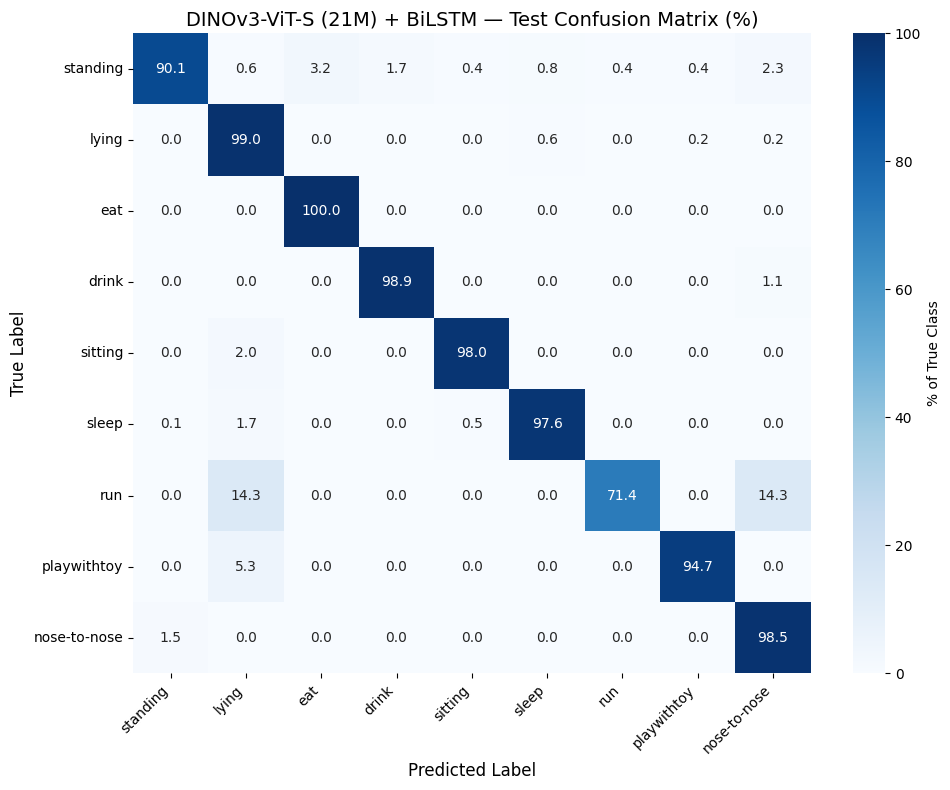

Saved: cm_percentage_dinov3_vits.png/pdf


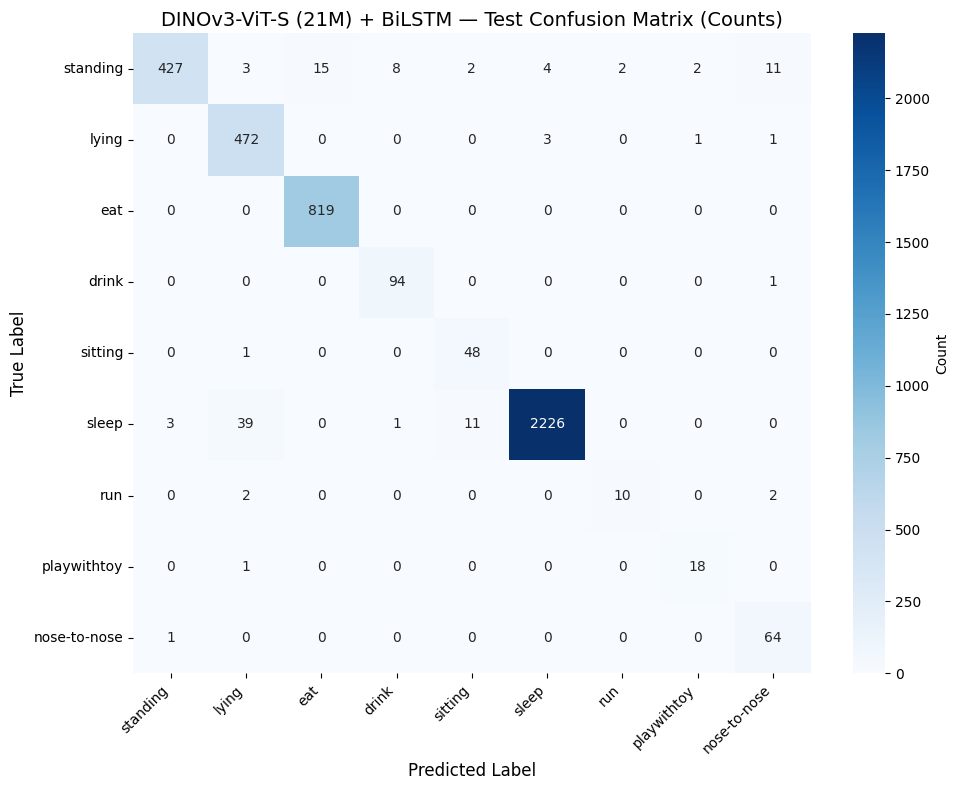

Saved: cm_counts_dinov3_vits.png/pdf


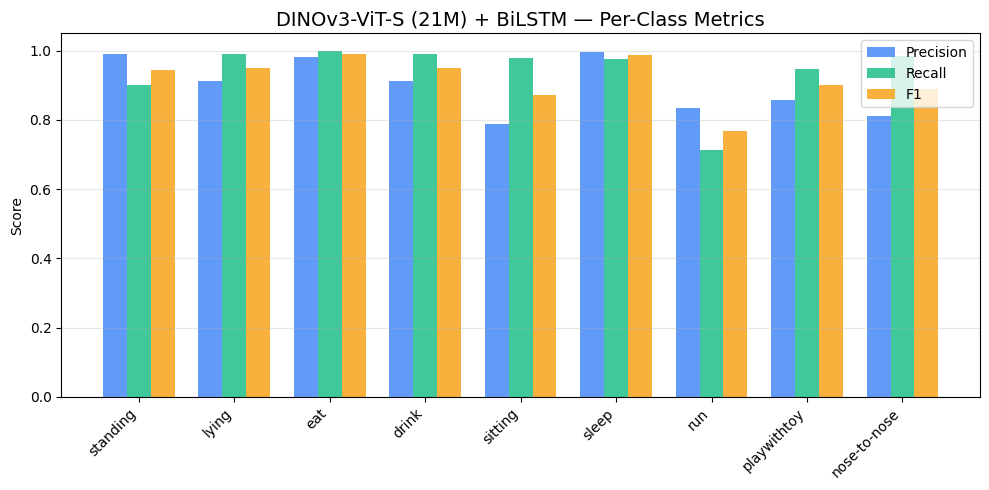

Saved: per_class_metrics_dinov3_vits.png/pdf


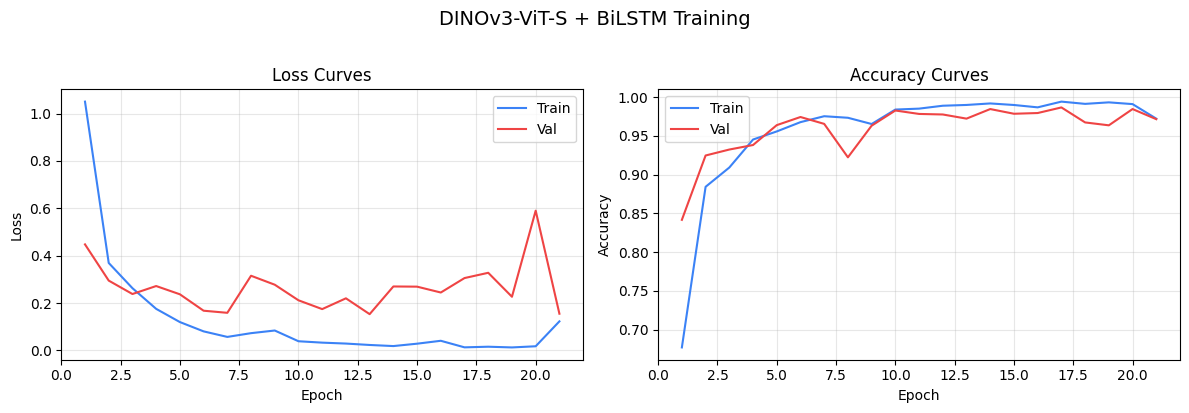

Saved: training_curves_dinov3_vits.png


In [0]:

# CONFUSION MATRIX FIGURES
# ── Figure 1: Percentage Confusion Matrix ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    vmin=0, vmax=100,
    xticklabels=WANTED_BEH, yticklabels=WANTED_BEH,
    cbar_kws={'label': '% of True Class'},
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('DINOv3-ViT-S (21M) + BiLSTM — Test Confusion Matrix (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

fig.savefig(osp.join(FIGURE_DIR, 'cm_percentage_dinov3_vits.png'), dpi=300, bbox_inches='tight')
fig.savefig(osp.join(FIGURE_DIR, 'cm_percentage_dinov3_vits.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved: cm_percentage_dinov3_vits.png/pdf")


# ── Figure 2: Raw Count Confusion Matrix ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=WANTED_BEH, yticklabels=WANTED_BEH,
    cbar_kws={'label': 'Count'},
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('DINOv3-ViT-S (21M) + BiLSTM — Test Confusion Matrix (Counts)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

fig.savefig(osp.join(FIGURE_DIR, 'cm_counts_dinov3_vits.png'), dpi=300, bbox_inches='tight')
fig.savefig(osp.join(FIGURE_DIR, 'cm_counts_dinov3_vits.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved: cm_counts_dinov3_vits.png/pdf")


# ── Figure 3: Per-Class F1 Bar Chart ───────────────────────────────────────
prec, rec, f1_per, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(num_classes)), zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(num_classes)
width = 0.25

ax.bar(x - width, prec, width, label='Precision', color='#3B82F6', alpha=0.8)
ax.bar(x, rec, width, label='Recall', color='#10B981', alpha=0.8)
ax.bar(x + width, f1_per, width, label='F1', color='#F59E0B', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(WANTED_BEH, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('DINOv3-ViT-S (21M) + BiLSTM — Per-Class Metrics', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

fig.savefig(osp.join(FIGURE_DIR, 'per_class_metrics_dinov3_vits.png'), dpi=300, bbox_inches='tight')
fig.savefig(osp.join(FIGURE_DIR, 'per_class_metrics_dinov3_vits.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved: per_class_metrics_dinov3_vits.png/pdf")


# ── Figure 4: Training Curves ──────────────────────────────────────────────
hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_df['epoch'], hist_df['tr_loss'], label='Train', color='#3B82F6')
ax1.plot(hist_df['epoch'], hist_df['val_loss'], label='Val', color='#EF4444')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(hist_df['epoch'], hist_df['tr_acc'], label='Train', color='#3B82F6')
ax2.plot(hist_df['epoch'], hist_df['val_acc'], label='Val', color='#EF4444')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('DINOv3-ViT-S + BiLSTM Training', fontsize=14, y=1.02)
plt.tight_layout()

fig.savefig(osp.join(FIGURE_DIR, 'training_curves_dinov3_vits.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: training_curves_dinov3_vits.png")

## Cell 13: Final Summary Report

In [0]:
## Cell 12.5: Load Cached Benchmark Results
# Bypasses the need to re-run Cell 6 after a cluster restart

# Reconstructing the batched throughput from previous output
extraction_speed = [
    {'batch_size': 1,  'total_ms': 6.68,  'per_img_ms': 6.68},
    {'batch_size': 8,  'total_ms': 6.83,  'per_img_ms': 0.85},
    {'batch_size': 16, 'total_ms': 6.72,  'per_img_ms': 0.42},
    {'batch_size': 32, 'total_ms': 14.77, 'per_img_ms': 0.46},
    {'batch_size': 64, 'total_ms': 28.86, 'per_img_ms': 0.45}
]

# Cell 13 expects single_times in seconds and multiplies by 1000. 
# Since your mean was 7.99 ms, we provide it as 0.00799 seconds.
single_times = [7.99 / 1000]

print("Successfully loaded cached extraction speed variables!")

Successfully loaded cached extraction speed variables!


In [0]:

# FINAL SUMMARY


print(f"\n{'#'*70}")
print(f"  FINAL SUMMARY — DINOv3-ViT-S (21M) Behavior Classification")
print(f"{'#'*70}")

print(f"\n  Model:")
print(f"    Backbone:        {MODEL_NAME}")
print(f"    Backbone params: {n_params/1e6:.2f}M")
print(f"    Backbone size:   {n_params*4/1024**2:.1f} MB (fp32) / {n_params*2/1024**2:.1f} MB (fp16)")
print(f"    Running dtype:   {MODEL_DTYPE}")
print(f"    Embedding dim:   {EMB_DIM}")
print(f"    Classifier:      BiLSTM ({lstm_params/1e3:.1f}K params)")
print(f"    Seq length:      {SEQ_LEN} (stride={SEQ_STRIDE})")

print(f"\n  Comparison to ViT-7B teacher:")
print(f"    {'Metric':<25} {'ViT-7B':>12} {'ViT-S':>12} {'Ratio':>10}")
print(f"    {'-'*60}")
print(f"    {'Parameters':<25} {'6,716M':>12} {f'{n_params/1e6:.0f}M':>12} {6716/n_params*1e6:>9.0f}x")
print(f"    {'Embedding dim':<25} {'4096':>12} {f'{EMB_DIM}':>12} {4096/EMB_DIM:>9.1f}x")
print(f"    {'Size (fp32)':<25} {'~25 GB':>12} {f'{n_params*4/1024**2:.0f} MB':>12} {'':>10}")

print(f"\n  Classification Performance (test set):")
print(f"    Accuracy:       {test_acc*100:.1f}%")
print(f"    Macro F1:       {macro_f1*100:.1f}%")
print(f"    Weighted F1:    {weighted_f1*100:.1f}%")

print(f"\n  Feature Extraction Speed ({DEVICE}):")
if extraction_speed:
    best_batch = min(extraction_speed, key=lambda x: x['per_img_ms'])
    print(f"    Single image:   {np.mean(single_times)*1000:.2f} ms")
    print(f"    Best batched:   {best_batch['per_img_ms']:.2f} ms/img "
          f"(batch={best_batch['batch_size']})")
    print(f"    Peak throughput: {1000/best_batch['per_img_ms']:.0f} img/s")

print(f"\n  LSTM Inference Speed:")
print(f"    Per window:     {np.mean(lstm_times)*1000:.3f} ms")

print(f"\n  Per-class breakdown:")
print(f"    {'Behavior':<18} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print(f"    {'-'*60}")
for i, beh in enumerate(WANTED_BEH):
    print(f"    {beh:<18} {prec[i]:>10.3f} {rec[i]:>10.3f} {f1_per[i]:>10.3f} {int(sup[i]):>10}")

print(f"\n  Top 5 confused pairs:")
for cp in confused_pairs[:5]:
    print(f"    {cp['true']} → {cp['predicted']}: "
          f"{cp['count']} samples ({cp['pct_of_true']:.1f}%)")

print(f"\n  Output files:")
print(f"    Metadata:   {META_OUT_CSV}")
print(f"    Embeddings: {EMB_OUT_BASE}/")
print(f"    Figures:    {FIGURE_DIR}/")
print(f"    Model:      best_bilstm_dinov3.pt")

# ── Save JSON report ───────────────────────────────────────────────────────
report = {
    'model': MODEL_NAME,
    'backbone_params_M': n_params / 1e6,
    'embedding_dim': EMB_DIM,
    'lstm_params_K': lstm_params / 1e3,
    'seq_len': SEQ_LEN,
    'seq_stride': SEQ_STRIDE,
    'test_accuracy': float(test_acc),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'per_class_f1': {beh: float(f1_per[i]) for i, beh in enumerate(WANTED_BEH)},
    'per_class_precision': {beh: float(prec[i]) for i, beh in enumerate(WANTED_BEH)},
    'per_class_recall': {beh: float(rec[i]) for i, beh in enumerate(WANTED_BEH)},
    'top_confused_pairs': confused_pairs[:10],
    'extraction_speed': extraction_speed,
    'lstm_latency_ms': float(np.mean(lstm_times) * 1000),
    'confusion_matrix_pct': cm_pct.tolist(),
}

# Log final test metrics to MLflow (best-effort)
if mlflow_run_id:
    try:
        with mlflow.start_run(run_id=mlflow_run_id):
            mlflow.log_metrics({
                'test_accuracy': float(test_acc),
                'test_macro_f1': float(macro_f1),
                'test_weighted_f1': float(weighted_f1),
            })
            for fig_file in os.listdir(FIGURE_DIR):
                if fig_file.endswith(('.png', '.pdf')):
                    mlflow.log_artifact(osp.join(FIGURE_DIR, fig_file))
        print(f"  MLflow: logged test metrics to run {mlflow_run_id}")
    except Exception as e:
        print(f"  MLflow logging skipped ({e}) — results saved to JSON below")
else:
    print("  MLflow: no run ID available — results saved to JSON below")

report_path = osp.join(FIGURE_DIR, 'dinov3_vits_classification_report.json')
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)
print(f"\nSaved report: {report_path}")

print(f"\n{'#'*70}")
print(f"  NEXT STEPS:")
print(f"  1. Run same pipeline with DINOv3-ViT-7B embeddings for comparison")
print(f"  2. If accuracy gap > 3%, try DINOv3-ViT-B (86M, dim=768)")
print(f"  3. If accuracy gap < 3%, proceed to Jetson deployment")
print(f"  4. Consider adding Re-ID head for tracking robustness")
print(f"{'#'*70}")


######################################################################
  FINAL SUMMARY — DINOv3-ViT-S (21M) Behavior Classification
######################################################################

  Model:
    Backbone:        facebook/dinov3-vits16-pretrain-lvd1689m
    Backbone params: 21.60M
    Backbone size:   82.4 MB (fp32) / 41.2 MB (fp16)
    Running dtype:   torch.float16
    Embedding dim:   384
    Classifier:      BiLSTM (560.4K params)
    Seq length:      3 (stride=1)

  Comparison to ViT-7B teacher:
    Metric                          ViT-7B        ViT-S      Ratio
    ------------------------------------------------------------
    Parameters                      6,716M          22M       311x
    Embedding dim                     4096          384      10.7x
    Size (fp32)                     ~25 GB        82 MB           

  Classification Performance (test set):
    Accuracy:       97.3%
    Macro F1:       91.7%
    Weighted F1:    97.4%

  Feature Extracti